## Import Packages

In [80]:
# set libraries to refresh
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [81]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from matplotlib.colors import ListedColormap
from shapely import MultiPolygon
from shapely.geometry import Polygon
from shapely.strtree import STRtree
from sklearn.cluster import DBSCAN
from tqdm.notebook import tqdm

In [82]:
from gridsample.utils import create_ids, save_shapefiles
from gridsample.utils_rooftop import generate_colormap
from gridsample.mapping.plot import create_interactive_map

In [83]:
from utils import get_steep_shapes

## Set Global Params

### Folder Paths

In [84]:
LOCATION = "Barwani"

In [85]:
ROOT_DIR = Path("../")
DATA_DIR = ROOT_DIR / "data"
RAW_DATA_DIR = DATA_DIR / "00_raw"
PROCESSED_DATA_DIR = (
    DATA_DIR / "01_processed" / "Solar Parks" / LOCATION / "01 Processed Data"
)
OUTPUT_DATA_DIR = (
    DATA_DIR / "01_processed" / "Solar Parks" / LOCATION / "02 Outputs" / "v4"
)

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)

### Code Parameters

In [86]:
INDIA_PROJECTED_CRS = "24378"

In [87]:
BACKGROUND_COLOR = "lightgreen"
BUILDING_COLOR = "yellow"
SETTLEMENT_COLOR = "darkred"
WATER_COLOR = "C0"
CROPLAND_COLOR = "goldenrod"
SLOPE_COLOR = "grey"

## Custom Functions

In [88]:
def clean_non_polygons(gdf):
    """
    Clean Geometry Collections and MultiPolygons by keeping only Polygons inside
    and dropping points or lines etc.
    """

    def _clean_geom(geom):
        if geom is None:
            return Polygon()

        # If it's already a Polygon, return as is
        if geom.geom_type == "Polygon":
            return geom

        # Get polygons from MultiPolygon or GeometryCollection
        polygons = []
        if hasattr(geom, "geoms"):
            for g in geom.geoms:
                if g.geom_type == "Polygon":
                    polygons.append(g)

        # Return appropriate geometry based on number of polygons found
        if not polygons:
            return Polygon()
        if len(polygons) == 1:
            return polygons[0]
        return MultiPolygon(polygons)

    # Apply cleaning and set invalid geometries to None
    gdf = gdf.copy()
    gdf.geometry = gdf.geometry.apply(_clean_geom)
    return gdf

In [89]:
def difference_overlay_without_discard(gdf1, gdf2):
    overlay_gdf = gpd.overlay(
        gdf1.reset_index(names="original_index"),
        gdf2,
        how="difference",
        keep_geom_type=True,
    )

    # Create a copy to modify
    gdf1_v2 = gdf1.copy()
    # By default, set all geometries to an empty Polygon
    gdf1_v2["geometry"] = Polygon()
    # Update the geometries for the rows that still exist after the overlay
    gdf1_v2.loc[overlay_gdf["original_index"], "geometry"] = overlay_gdf.geometry.values

    gdf1_v2 = clean_non_polygons(gdf1_v2)

    return gdf1_v2

In [90]:
# for TIFF files
import rasterio
from rasterio.features import shapes
from rasterio.plot import show
from shapely.geometry import shape


def get_landcover_shapes(
    landcover_data,
    transform,
    class_name,
    class_value_lookup_dict,
    raster_crs="4326",
    target_crs="24378",
):
    # Get array values
    class_values = class_value_lookup_dict[class_name]

    # Create mask
    layer_mask = np.isin(landcover_data, class_values)

    # Extract vector shapes and make a GeoDataFrame
    vector_shapes = [
        {"geometry": shape(geom), "properties": {"class": class_name}}
        for geom, class_value in shapes(
            landcover_data, mask=layer_mask, transform=transform
        )
    ]
    shapes_gdf = gpd.GeoDataFrame(vector_shapes, crs=raster_crs)
    shapes_gdf = shapes_gdf.to_crs(target_crs)

    return shapes_gdf

In [91]:
def build_optimised_distance_matrix(gdf, max_distance_considered, n_jobs=-1):
    """
    Build an optimized distance matrix for the given GeoDataFrame.

    Parameters
    ----------
    gdf : GeoDataFrame
        The input GeoDataFrame.
    max_distance_considered : float
        The maximum distance to consider for clustering.
    n_jobs : int, optional
        The number of jobs to run in parallel (default is -1, which uses all available cores).

    Returns
    -------
    np.ndarray
        The optimized distance matrix.
    """
    # Prepare geoms and build a spatial index (STRtree) for fast neighbor queries
    geometries = gdf.geometry.values
    n = len(geometries)
    tree = STRtree(geometries)

    # Prepare distance calculator
    def _get_distances_for_geom(i, geom, geometries, tree, max_distance_considered):
        """Calculates distances for a single geometry to its neighbors."""
        distances = []
        # Query the STRtree to find potential neighbors within the buffer
        candidate_indices = tree.query(geom.buffer(max_distance_considered))
        for j in candidate_indices:
            if i == j:
                continue
            geom_candidate = geometries[j]
            d = geom.distance(geom_candidate)
            distances.append((i, j, d))
        return distances

    # Run the distance calculation in parallel
    results = Parallel(n_jobs=n_jobs)(
        delayed(_get_distances_for_geom)(
            i, geom, geometries, tree, max_distance_considered
        )
        for i, geom in enumerate(tqdm(geometries, desc="Building distance matrix"))
    )

    # Initialize full matrix with initial value too high to be considered by DBSCAN when clustering
    distance_matrix = np.full((n, n), 99999)
    # Populate the distance matrix
    for res_list in results:
        for i, j, d in res_list:
            distance_matrix[i, j] = d

    # Set diagonal to zero for self-distances
    np.fill_diagonal(distance_matrix, 0)

    return distance_matrix

In [92]:
def format_DBSCAN_cluster_labels(
    gdf_with_stats_and_cluster_id: gpd.GeoDataFrame,
    cluster_id_col: str,
    distance_threshold: int | None = None,
    area_col: str = "Usable Area (ha)",
):
    # filter to only clustered rows
    clustered_rows_df = gdf_with_stats_and_cluster_id[
        gdf_with_stats_and_cluster_id[cluster_id_col] != -1
    ]

    # get cluster labels with sizes
    cluster_labels_with_sizes_df = (
        clustered_rows_df.groupby(cluster_id_col)[area_col].sum()
    ).reset_index()

    # sort cluster labels by size
    ordered_cluster_labels_df = cluster_labels_with_sizes_df.sort_values(
        by=area_col, ascending=False
    )

    # add labels starting from largest size as parcel 1 and so on
    if distance_threshold:
        ordered_cluster_labels_df["formatted_ids"] = create_ids(
            df_length=len(ordered_cluster_labels_df),
            prefix=f"PARCEL_{distance_threshold}m_",
        )
        cluster_mapping = {-1: f"PARCEL_{distance_threshold}m_UNCLUSTERED"}
    else:
        ordered_cluster_labels_df["formatted_ids"] = create_ids(
            df_length=len(ordered_cluster_labels_df), prefix="PARCEL_"
        )
        cluster_mapping = {-1: "PARCEL_UNCLUSTERED"}
    cluster_mapping.update(
        dict(
            zip(
                ordered_cluster_labels_df[cluster_id_col],
                ordered_cluster_labels_df["formatted_ids"],
            )
        )
    )

    # reassign formatted_ids in the original GeoDataFrame with the new values
    gdf_with_stats_and_cluster_id[cluster_id_col] = gdf_with_stats_and_cluster_id[
        cluster_id_col
    ].map(cluster_mapping)

    return gdf_with_stats_and_cluster_id

## Load cleaned khasras

In [93]:
DISTRICT_MAPS_OUTPUT_DATA_DIR = OUTPUT_DATA_DIR / "District Maps"
DISTRICT_MAPS_OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)

In [94]:
barwani_gdf = gpd.read_parquet(
    PROCESSED_DATA_DIR / "Cleaned Khasras" / "barwani_cleaned_khasras.parquet"
)
barwani_gdf

,Khasra ID (Unique),Tehsil Code,Village Name,BHU Code,Noiyat,ROR KID,Patch Name,Khasra ID,Original Area (ha),Noiyat Unusable Area (ha),Noiyat Unusable Area (%),geometry
1020,121/1 (BWI1004),3560.0,Vajhar,4.906010e+13,"ना.का.च. 2.2700, ना.का.च. 0.1010","121/1, 121/8",BWI1004,121/1,2.212400,0.000,0.00,"MULTIPOLYGON (((74.94480 21.72542, 74.94487 21..."
1024,121/2 (BWI1004),NaN,None,NaN,None,None,BWI1004,121/2,0.050566,0.000,0.00,"POLYGON ((74.94475 21.72560, 74.94471 21.72577..."
1042,122 (BWI1004),3560.0,Vajhar,4.906010e+13,"का.का. 0.4830, का.का. 0.0690, का.का. 0.0320","122/1, 122/5, 122/4",BWI1004,122,1.121047,0.584,52.09,"POLYGON ((74.94874 21.72558, 74.94874 21.72568..."
1075,123 (BWI1004),NaN,None,NaN,None,None,BWI1004,123,1.078574,0.000,0.00,"POLYGON ((74.94837 21.72466, 74.94835 21.72466..."
1111,124 (BWI1004),3560.0,Vajhar,4.906010e+13,"का.का. 0.2020, चारागाह 2.5510, का.का. 0....","124/5, 124/1, 124/4, 124/6",BWI1004,124,3.787275,2.427,64.08,"POLYGON ((74.94844 21.72468, 74.94844 21.72474..."
...,...,...,...,...,...,...,...,...,...,...,...,...
5573,302/1 (BWI995),3560.0,Vajhar,4.906010e+13,चारागाह 6.8260,"302/1, 302/8",BWI995,302/1,8.111402,0.000,0.00,"POLYGON ((74.94023 21.72161, 74.93989 21.72167..."
5622,305 (BWI995),3560.0,Vajhar,4.906010e+13,चारागाह 2.7700,"305/1, 305/3",BWI995,305,2.956532,0.000,0.00,"POLYGON ((74.93846 21.72037, 74.93847 21.72058..."
5666,308 (BWI995),3560.0,Vajhar,4.906010e+13,चारागाह 1.4530,308/1,BWI995,308,1.279175,0.000,0.00,"POLYGON ((74.93739 21.71696, 74.93728 21.71705..."
5761,310 (BWI995),NaN,None,NaN,None,None,BWI995,310,1.993618,0.000,0.00,"POLYGON ((74.93587 21.71845, 74.93560 21.71848..."


In [95]:
gdf_4326 = barwani_gdf
gdf = barwani_gdf.to_crs(INDIA_PROJECTED_CRS)

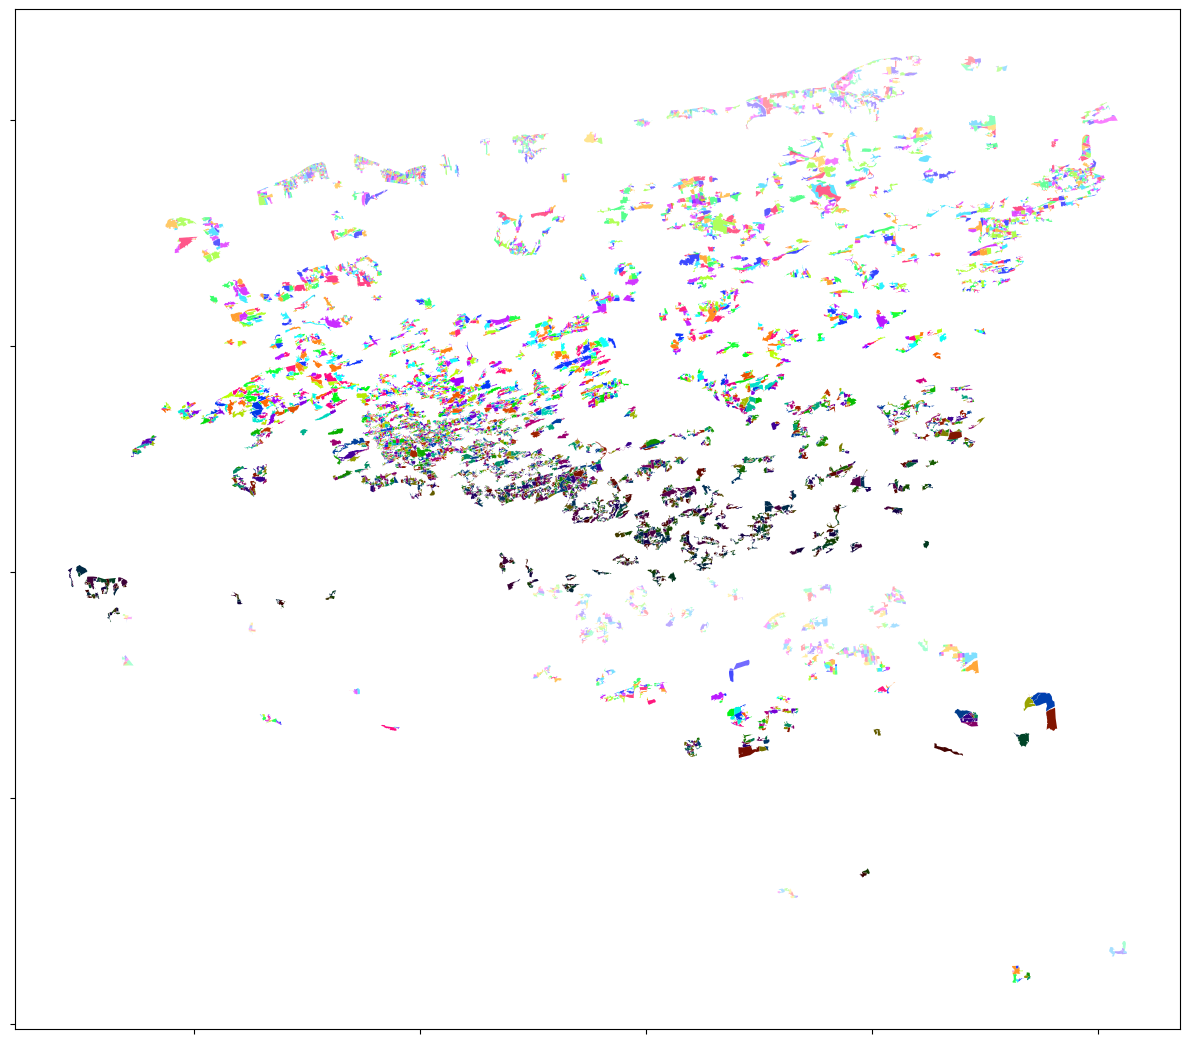

In [96]:
ax = gdf.plot(
    cmap=ListedColormap(generate_colormap(len(gdf))),
    figsize=(12, 12),
)
ax.set_xticklabels([])
ax.set_yticklabels([])

plt.tight_layout()
plt.savefig(
    DISTRICT_MAPS_OUTPUT_DATA_DIR / "khasras.png",
    dpi=300,
    bbox_inches="tight",
)

In [97]:
save_shapefiles(
    gdf.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Khasra Shapefiles",
    "khasras_initial",
    formats=["parquet", "kml", "csv"],
)

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value '121/1, 121/8' of field khasras_initial.BHU Code parsed incompletely to real 121.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value '122/1, 122/5, 122/4' of field khasras_initial.BHU Code parsed incompletely to real 122.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value '124/5, 124/1, 124/4, 124/6' of field khasras_initial.BHU Code parsed incompletely to real 124.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value '125/3, 125/1' of field khasras_initial.BHU Code parsed incompletely to real 125.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value '127/1, 127/3' of field 

## Unusable layers

Overlap layers and decide which to discard and which to take forward

### Buildings

In [98]:
from gridsample.utils_rooftop import (
    download_VIDA_rooftops_data_by_s2,
    get_overlapping_s2_cell_ids,
    get_s2_cell_polygons,
)

#### Identify S2 cell IDs

In [99]:
s2_cell_ids = get_overlapping_s2_cell_ids(gdf_4326)
print("Number of unique S2 cell IDs that overlap these shapes:", len(s2_cell_ids))
print("Unique S2 cell IDs:", s2_cell_ids)

/Users/amiremami/IDinsight Repos/gridsample/gridsample/utils_rooftop.py:125: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points = gdf.geometry.centroid.to_frame(name="geometry")


Shapes with spillover after round 1: 0
Number of unique S2 cell IDs that overlap these shapes: 4
Unique S2 cell IDs: [4314166968044224512, 4312478118183960576, 4134585932902825984, 4135148882856247296]


#### Check if identified cells cover all areas of interest


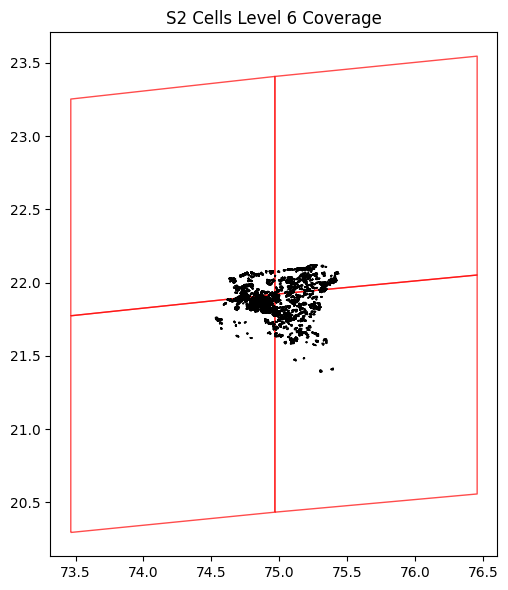

In [ ]:
s2_cells_gdf = get_s2_cell_polygons(s2_cell_ids)

# Plot the S2 cells and the boundary
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
gdf_4326.boundary.plot(ax=ax, color="black", linewidth=1)
s2_cells_gdf.plot(ax=ax, facecolor="none", edgecolor="red", alpha=0.7)
plt.title("S2 Cells Level 6 Coverage")
plt.tight_layout()
plt.show()
# Does the S2 cell cover the entire area of the boundaries?
uncovered_area = gdf_4326.unary_union.difference(s2_cells_gdf.unary_union).area
print(f"{uncovered_area} square degrees area not covered by an S2 cell")


In [ ]:
#### Download the S2 cells
download_VIDA_rooftops_data_by_s2(
    s2_cell_ids=s2_cell_ids,
    country_iso_code="IND",
    target_data_dir=RAW_DATA_DIR / "rooftops",
)

#### Load and process rooftop data

In [ ]:
try:
    print("Checking for existing filtered rooftops...")
    subset_rooftops_gdf = gpd.read_parquet(
        PROCESSED_DATA_DIR / "Filtered Rooftops" / "rooftops.parquet"
    )
    print("Loaded existing filtered rooftops.")
except FileNotFoundError:
    print("No saved filtered rooftops found, processing raw data...")
    rooftop_gdf_list = []
    for s2_cell_id in s2_cell_ids:
        s2_rooftops_path = RAW_DATA_DIR / "rooftops" / f"{s2_cell_id}.parquet"
        rooftop_gdf = gpd.read_parquet(s2_rooftops_path)
        rooftop_gdf_list.append(rooftop_gdf)

    rooftop_gdf = pd.concat(rooftop_gdf_list, ignore_index=True)
    rooftop_gdf = rooftop_gdf[
        [
            "bf_source",
            "confidence",
            "area_in_meters",
            "geometry",
        ]
    ]

    rooftop_gdf["rooftop_id"] = create_ids(
        len(rooftop_gdf), f"ROOFTOP_S2_{s2_cell_id}_"
    )
    rooftop_gdf = rooftop_gdf.to_crs(INDIA_PROJECTED_CRS)

    # Filter to only rooftops that overlap the parcels
    subset_rooftops_gdf = rooftop_gdf.sjoin(
        gdf, how="inner", predicate="intersects"
    ).drop(columns=["index_right"])
    subset_rooftops_gdf.drop(columns=gdf.columns.drop("geometry"), inplace=True)

    save_shapefiles(
        subset_rooftops_gdf,
        PROCESSED_DATA_DIR / "Filtered Rooftops",
        "rooftops",
        formats=["parquet"],
    )

In [ ]:
buffer = 10
buffered_rooftops_gdf = subset_rooftops_gdf.copy()
buffered_rooftops_gdf["geometry"] = buffered_rooftops_gdf.buffer(buffer)

# get cutout of the buffered building shapes that overlap parcels
buildings_overlap_gdf = gpd.overlay(buffered_rooftops_gdf, gdf, how="intersection")

#### Settlements

Try different thresholds

In [ ]:
# for eps in [200, 250, 300]:
#     clusterer = DBSCAN(eps=eps, min_samples=10, n_jobs=-1)
#     building_centroids = buildings_overlap_gdf.geometry.centroid
#     X = np.array(list(zip(building_centroids.x, building_centroids.y)))
#     building_cluster_ids = clusterer.fit_predict(X)
#     buildings_overlap_gdf["settlement_id"] = building_cluster_ids

#     settlement_buildings_gdf = buildings_overlap_gdf[
#         buildings_overlap_gdf["settlement_id"] != -1
#     ]
#     isolated_buildings_gdf = buildings_overlap_gdf[
#         buildings_overlap_gdf["settlement_id"] == -1
#     ]

#     # get the convex hull of each cluster
#     settlements_gdf = settlement_buildings_gdf.dissolve(by="settlement_id").reset_index()
#     settlements_gdf = settlements_gdf[["geometry", "settlement_id"]]
#     settlements_gdf.geometry = settlements_gdf.convex_hull

#     # get cutout of the buffered building shapes that overlap parcels
#     settlements_gdf = gpd.overlay(settlements_gdf, gdf, how="intersection")
#     settlements_gdf = settlements_gdf[["Khasra ID (Unique)", "settlement_id", "geometry"]]

#     # plot
#     ax = gdf.plot(figsize=(20, 20))
#     settlements_gdf.plot(ax=ax, color=SETTLEMENT_COLOR)
#     settlement_buildings_gdf.plot(ax=ax, color="red")
#     isolated_buildings_gdf.buffer(20).plot(ax=ax, color=BUILDING_COLOR)

#     # add stats
#     total_count = len(buildings_overlap_gdf)
#     settlement_count = len(settlement_buildings_gdf)
#     perc_settlement_buildings = settlement_count / total_count * 100
#     isolated_count = len(isolated_buildings_gdf)
#     total_area = buildings_overlap_gdf.area.sum() / 10_000
#     settlement_area = settlements_gdf.area.sum() / 10_000
#     title = f"""
#     Buildings at {eps}m eps
#     Total Buildings: {total_count}
#     Settlement Buildings: {settlement_count} ({perc_settlement_buildings:.2f}%)
#     Total Building Area (ha): {total_area:.2f}
#     Settlement Area (ha): {settlement_area:.2f}
#     """
#     ax.set_title(title, fontsize=12)
#     ax.set_xticklabels([])
#     ax.set_yticklabels([])

#     plt.savefig(
#         DISTRICT_MAPS_OUTPUT_DATA_DIR / f"settlements_{eps}.png", dpi=300, bbox_inches='tight'
#     )

Run for the chosen threshold

In [ ]:
CHOSEN_EPS = 50
MIN_BUILDINGS = 5
clusterer = DBSCAN(eps=CHOSEN_EPS, min_samples=MIN_BUILDINGS, n_jobs=-1)

building_centroids = buildings_overlap_gdf.geometry.centroid
X = np.array(list(zip(building_centroids.x, building_centroids.y)))
building_cluster_ids = clusterer.fit_predict(X)

buildings_overlap_gdf["settlement_id"] = building_cluster_ids

settlement_buildings_gdf = buildings_overlap_gdf[
    buildings_overlap_gdf["settlement_id"] != -1
]
isolated_buildings_gdf = buildings_overlap_gdf[
    buildings_overlap_gdf["settlement_id"] == -1
]

# get the convex hull of each cluster
settlements_gdf = settlement_buildings_gdf.dissolve(by="settlement_id").reset_index()
settlements_gdf = settlements_gdf[["geometry", "settlement_id"]]
settlements_gdf.geometry = settlements_gdf.convex_hull

# get cutout of the buffered building shapes that overlap parcels
settlements_gdf = gpd.overlay(settlements_gdf, gdf, how="intersection")
settlements_gdf = settlements_gdf[["Khasra ID (Unique)", "settlement_id", "geometry"]]

In [ ]:
building_counts_df = (
    buildings_overlap_gdf.groupby("Khasra ID (Unique)")
    .size()
    .reset_index(name="Building Count")
)
building_counts_df

In [ ]:
isolated_buildings_overlap_gdf = isolated_buildings_gdf.dissolve(
    by="Khasra ID (Unique)"
).reset_index()
settlement_buildings_overlap_gdf = settlement_buildings_gdf.dissolve(
    by="Khasra ID (Unique)"
).reset_index()

In [ ]:
isolated_buildings_overlap_gdf["Unavailable Area - Isolated Buildings (ha)"] = (
    isolated_buildings_overlap_gdf.area / 10_000
)
isolated_buildings_unusable_area_df = isolated_buildings_overlap_gdf[
    ["Khasra ID (Unique)", "Unavailable Area - Isolated Buildings (ha)"]
]

In [ ]:
settlements_overlap_gdf = settlements_gdf.dissolve(
    by="Khasra ID (Unique)"
).reset_index()
settlements_overlap_gdf["Unusable Area - Settlements (ha)"] = (
    settlements_overlap_gdf.area / 10_000
)
settlements_unusable_area_df = settlements_overlap_gdf[
    ["Khasra ID (Unique)", "Unusable Area - Settlements (ha)"]
]

### Landcover (Cropland, Water)

#### Landcover

In [ ]:
path = "../data/00_raw/landcover/30N_070E_2020.tif"
src = rasterio.open(path)

In [ ]:
masked_landcover_data, masked_transform = rasterio.mask.mask(
    src, [gdf_4326.unary_union], crop=True
)
masked_landcover_data = np.squeeze(masked_landcover_data)
show(masked_landcover_data)

In [ ]:
# load value to landcover type mapping legend
legend_df = pd.read_csv(RAW_DATA_DIR / "landcover" / "legend_processed.csv")
landcover_value_class_dict = legend_df.set_index("map_value")["class_b"].to_dict()

landcover_class_value_dict = {}
for key, value in landcover_value_class_dict.items():
    if value not in landcover_class_value_dict:
        landcover_class_value_dict[value] = [key]
    else:
        landcover_class_value_dict[value].append(key)

#### Cropland

In [ ]:
cropland_shapes_gdf = get_landcover_shapes(
    masked_landcover_data,
    masked_transform,
    class_name="Cropland",
    class_value_lookup_dict=landcover_class_value_dict,
    raster_crs=src.crs,
    target_crs=INDIA_PROJECTED_CRS,
)

In [ ]:
# get cutout of the water shapes that overlap parcels
cropland_overlap_gdf = gpd.overlay(cropland_shapes_gdf, gdf, how="intersection")
cropland_overlap_gdf = cropland_overlap_gdf.dissolve(
    by="Khasra ID (Unique)"
).reset_index()

In [ ]:
cropland_overlap_gdf["Unavailable Area - Cropland (ha)"] = (
    cropland_overlap_gdf.area / 10_000
)
cropland_unusable_area_df = cropland_overlap_gdf[
    ["Khasra ID (Unique)", "Unavailable Area - Cropland (ha)"]
]

#### Water

In [ ]:
water_shapes_gdf = get_landcover_shapes(
    masked_landcover_data,
    masked_transform,
    class_name="Open surface water",
    class_value_lookup_dict=landcover_class_value_dict,
    raster_crs=src.crs,
    target_crs=INDIA_PROJECTED_CRS,
)

In [ ]:
# get cutout of the water shapes that overlap parcels
water_overlap_gdf = gpd.overlay(water_shapes_gdf, gdf, how="intersection")
water_overlap_gdf = water_overlap_gdf.dissolve(by="Khasra ID (Unique)").reset_index()

In [ ]:
water_overlap_gdf["Unusable Area - Water (ha)"] = water_overlap_gdf.area / 10_000
water_unusable_area_df = water_overlap_gdf[
    ["Khasra ID (Unique)", "Unusable Area - Water (ha)"]
]

#### Trees (not used right now)

In [ ]:
tree_shapes_gdf = get_landcover_shapes(
    masked_landcover_data,
    masked_transform,
    class_name="Tree cover",
    class_value_lookup_dict=landcover_class_value_dict,
    raster_crs=src.crs,
    target_crs=INDIA_PROJECTED_CRS,
)

In [ ]:
# get cutout of the tree shapes that overlap parcels
tree_overlap_gdf = gpd.overlay(tree_shapes_gdf, gdf, how="intersection")
tree_overlap_gdf = tree_overlap_gdf.dissolve(by="Khasra ID (Unique)").reset_index()

In [ ]:
tree_overlap_gdf["Unusable Area - Tree Cover (ha)"] = tree_overlap_gdf.area / 10_000
tree_unusable_area_df = tree_overlap_gdf[
    ["Khasra ID (Unique)", "Unusable Area - Tree Cover (ha)"]
]
tree_unusable_area_df

### Slope

#### Download DEMs

Two sources:
1. ISRO Cartosat-1 (30m resolution): https://bhoonidhi.nrsc.gov.in/bhoonidhi/index.html
    - ISRO CartoDEM Version-3 R1, 30m resolution. The Cartosat-1 Digital Elevation Model (CartoDEM) is a National DEM developed by the Indian Space Research Organization (ISRO). It is derived from the Cartosat-1 stereo payload launched in May 2005. PDFs in folder.

2. NASA ALOS PALSAR (12.5m resolution): https://search.asf.alaska.edu/

##### ISRO

In [ ]:
# For ISRO, visit https://bhoonidhi.nrsc.gov.in/bhoonidhi/index.html
# input the bounds below download all tiles that overlap it
gdf_4326.total_bounds

##### NASA

In [ ]:
# for auto-downloading NASA DEMs
# `pip install asf-search`
import asf_search as asf

# get bounding box WKT
xmin, ymin, xmax, ymax = gdf_4326.total_bounds
bbox_poly = Polygon([
    (xmin, ymin),
    (xmax, ymin),
    (xmax, ymax),
    (xmin, ymax),
    (xmin, ymin)
])
wkt_string = bbox_poly.wkt

# perform search and convert result image bboxes to gdf
results = asf.geo_search(platform=[asf.PLATFORM.ALOS], processingLevel=asf.PRODUCT_TYPE.RTC_HIGH_RES, intersectsWith=wkt_string)
dem_images_gdf_4326 = gpd.GeoDataFrame.from_features(results.geojson()["features"]).set_crs(4326)

In [ ]:
ax = gdf_4326.plot(
    cmap=ListedColormap(generate_colormap(len(gdf))),
    figsize=(12, 12),
)
dem_images_gdf_4326.plot(ax=ax, column="fileID", alpha=0.4)

In [ ]:
# Reproject dem images (for accurate area calculations)
dem_images_gdf = dem_images_gdf_4326.to_crs(INDIA_PROJECTED_CRS)

# Select minimum number of DEM images that cover maximum area of our shapes
selected_images = []
remaining_patches = gdf.copy()
remaining_images = dem_images_gdf.copy()

while not remaining_patches.empty and not remaining_images.empty:
    # Calculate coverage area for each remaining image
    remaining_images["coverage_area"] = remaining_images.geometry.apply(
        lambda img: remaining_patches.intersection(img).area.sum()
    )

    # Find image with maximum coverage
    best_idx = remaining_images["coverage_area"].idxmax()
    best_image = remaining_images.loc[best_idx]

    # Stop if no new coverage is added
    if best_image["coverage_area"] == 0:
        break

    # Add to selected images
    selected_images.append(best_image)
    print(
        f"Selected image {len(selected_images)}: covers {best_image['coverage_area']/10000:.2f} ha"
    )

    # Remove covered patches and this image
    remaining_patches = remaining_patches[
        ~remaining_patches.intersects(best_image.geometry)
    ]
    remaining_images = remaining_images.drop(best_idx)

# Create final GeoDataFrame
selected_images_gdf = gpd.GeoDataFrame(selected_images).reset_index(drop=True)

print(f"\nSelected {len(selected_images_gdf)} DEM images")
print(f"Remaining uncovered area: {remaining_patches.area.sum()/10000:.2f} ha")

# Visualize
ax = gdf.plot(
    cmap=ListedColormap(generate_colormap(len(gdf))),
    figsize=(12, 12),
)
selected_images_gdf.plot(
    ax=ax,
    column="fileID",
    alpha=0.4,
    edgecolor="red",
    linewidth=2,
)
plt.title(f"Selected {len(selected_images_gdf)} DEM images")
plt.show()

In [ ]:
selected_urls = selected_images_gdf["url"].tolist()
selected_urls

In [ ]:
# read username and password from secrets.yaml and login
import yaml
with open("./secrets.yaml", "r") as f:
    secrets = yaml.safe_load(f)
session = asf.ASFSession().auth_with_creds(secrets["earthdata_username"], secrets["earthdata_password"])

In [ ]:
zip_files_dir = RAW_DATA_DIR / "elevation_nasa"

# check if any of the URLs have already been downloaded
existing_files = list(zip_files_dir.glob("*.zip"))
existing_urls = []
for file in existing_files:
    for url in selected_urls:
        if file.name in url:
            existing_urls.append(url)
urls_to_download = list(set(selected_urls) - set(existing_urls))
urls_to_download

In [ ]:
if urls_to_download:
    print(f"Downloading {len(urls_to_download)} new files...")
    asf.download_urls(
        urls=urls_to_download,
        path=zip_files_dir.as_posix(),
        session=session,
        processes=1,
    )

#### Process DEMs

When using the `pydem` package, angles are outputted in radians so we have to convert to degrees. Aspect is measured from the x-axis and counter-clockwise, making East 0 and North 90deg.

We choose between 45 and 135 since north is at 90! 0 is east, and rotates counter-clockwise.

https://grass.osgeo.org/grass-stable/manuals/r.slope.aspect.html

##### North and above 7 degrees

In [ ]:
## NASA: 12.5m resolution ##

slope_type = "north"
processed_slopes_filename = f"slopes_nasa_{slope_type}"

try:
    print("Checking for existing slope overlaps...")
    slope_overlap_gdf = gpd.read_parquet(
        PROCESSED_DATA_DIR / "Filtered Slopes" / f"{processed_slopes_filename}.parquet"
    )
    print("Loaded existing slope overlaps.")

except FileNotFoundError:
    print("No saved slope overlaps found, processing raw data...")
    input_crs = 32643
    dem_filenames = [
        "AP_08864_FBD_F0420_RT1.dem",
        "AP_02650_FBS_F0420_RT1.dem",
        "AP_08864_FBD_F0430_RT1.dem",
        "AP_02650_FBS_F0410_RT1.dem",
        "AP_19177_FBD_F0420_RT1.dem",
    ]
    steep_shapes_gdf_list = []
    for dem_filename in dem_filenames:
        dem_folderpath = RAW_DATA_DIR / "elevation_nasa" / dem_filename.split(".dem")[0]
        steep_shapes_gdf = get_steep_shapes(
            dem_folderpath=dem_folderpath,
            dem_filename=dem_filename,
            input_crs=input_crs,
            output_crs=INDIA_PROJECTED_CRS,
            slope_type=slope_type,
            plot=True,
        )
        steep_shapes_gdf_list.append(steep_shapes_gdf)

    slope_shapes_gdf = pd.concat(steep_shapes_gdf_list, ignore_index=True)

    slope_overlap_gdf = gpd.overlay(
        slope_shapes_gdf, gdf, how="intersection", keep_geom_type=False
    )
    slope_overlap_gdf = slope_overlap_gdf.dissolve(
        by="Khasra ID (Unique)"
    ).reset_index()

    save_shapefiles(
        slope_overlap_gdf,
        PROCESSED_DATA_DIR / "Filtered Slopes",
        processed_slopes_filename,
        formats=["parquet"],
    )

In [ ]:
# ## ISRO: 30m resolution ##

# slope_type = "north"
# processed_slopes_filename = f"slopes_isro_{slope_type}"

# try:
#     print("Checking for existing slope overlaps...")
#     slope_overlap_gdf = gpd.read_parquet(
#         PROCESSED_DATA_DIR / "Filtered Slopes" / f"{processed_slopes_filename}.parquet"
#     )
#     print("Loaded existing slope overlaps.")
# except FileNotFoundError:
#     print("No saved slope overlaps found, processing raw data...")
#     input_crs = 4326
#     dem_filenames = [
#         "P5_PAN_CD_N21_000_E074_000_DEM_30m",
#         "P5_PAN_CD_N21_000_E075_000_DEM_30m",
#         "P5_PAN_CD_N22_000_E074_000_DEM_30m",
#         "P5_PAN_CD_N22_000_E075_000_DEM_30m",
#     ]

#     steep_shapes_gdf_list = []
#     for dem_filename in dem_filenames:
#         dem_folderpath = RAW_DATA_DIR / "elevation"
#         steep_shapes_gdf = get_steep_shapes(
#             dem_folderpath=dem_folderpath,
#             dem_filename=dem_filename,
#             input_crs=input_crs,
#             output_crs=INDIA_PROJECTED_CRS,
#             slope_type=slope_type,
#             plot=True,
#         )
#         steep_shapes_gdf_list.append(steep_shapes_gdf)

#     slope_shapes_gdf = pd.concat(steep_shapes_gdf_list, ignore_index=True)

#     slope_overlap_gdf = gpd.overlay(
#         slope_shapes_gdf, gdf, how="intersection", keep_geom_type=False
#     )
#     slope_overlap_gdf = slope_overlap_gdf.dissolve(
#         by="Khasra ID (Unique)"
#     ).reset_index()

#     save_shapefiles(
#         slope_overlap_gdf,
#         PROCESSED_DATA_DIR / "Filtered Slopes",
#         processed_slopes_filename,
#         formats=["parquet"],
#     )

In [ ]:
slope_overlap_gdf["Unusable Area - Slope (ha)"] = slope_overlap_gdf.area / 10_000
slope_unusable_area_df = slope_overlap_gdf[
    ["Khasra ID (Unique)", "Unusable Area - Slope (ha)"]
]

In [ ]:
ax = gdf.plot(color="lightgrey")
slope_overlap_gdf.buffer(100).plot(ax=ax, color="red")

##### Non-North and above 10 degrees

In [ ]:
## NASA: 12.5m resolution ##

slope_type = "other"
processed_slopes_filename = f"slopes_nasa_{slope_type}"

try:
    print("Checking for existing slope overlaps...")
    slope_overlap_other_gdf = gpd.read_parquet(
        PROCESSED_DATA_DIR / "Filtered Slopes" / f"{processed_slopes_filename}.parquet"
    )
    print("Loaded existing slope overlaps.")

except FileNotFoundError:
    print("No saved slope overlaps found, processing raw data...")
    input_crs = 32643
    dem_filenames = [
        "AP_08864_FBD_F0420_RT1.dem",
        "AP_02650_FBS_F0420_RT1.dem",
        "AP_08864_FBD_F0430_RT1.dem",
        "AP_02650_FBS_F0410_RT1.dem",
        "AP_19177_FBD_F0420_RT1.dem",
    ]
    steep_shapes_other_gdf_list = []
    for dem_filename in dem_filenames:
        dem_folderpath = RAW_DATA_DIR / "elevation_nasa" / dem_filename.split(".dem")[0]
        steep_shapes_other_gdf = get_steep_shapes(
            dem_folderpath=dem_folderpath,
            dem_filename=dem_filename,
            input_crs=input_crs,
            output_crs=INDIA_PROJECTED_CRS,
            slope_type=slope_type,
            plot=True,
        )
        steep_shapes_other_gdf_list.append(steep_shapes_other_gdf)

    slope_shapes_gdf = pd.concat(steep_shapes_other_gdf_list, ignore_index=True)

    slope_overlap_other_gdf = gpd.overlay(
        slope_shapes_gdf, gdf, how="intersection", keep_geom_type=False
    )
    slope_overlap_other_gdf = slope_overlap_other_gdf.dissolve(
        by="Khasra ID (Unique)"
    ).reset_index()

    save_shapefiles(
        slope_overlap_other_gdf,
        PROCESSED_DATA_DIR / "Filtered Slopes",
        processed_slopes_filename,
        formats=["parquet"],
    )

In [ ]:
# ## ISRO: 30m resolution ##

# slope_type = "other"
# processed_slopes_filename = f"slopes_isro_{slope_type}"

# try:
#     print("Checking for existing slope overlaps...")
#     slope_overlap_other_gdf = gpd.read_parquet(
#         PROCESSED_DATA_DIR / "Filtered Slopes" / f"{processed_slopes_filename}.parquet"
#     )
#     print("Loaded existing slope overlaps.")
# except FileNotFoundError:
#     print("No saved slope overlaps found, processing raw data...")
#     input_crs = 4326
#     dem_filenames = [
#         "P5_PAN_CD_N21_000_E074_000_DEM_30m",
#         "P5_PAN_CD_N21_000_E075_000_DEM_30m",
#         "P5_PAN_CD_N22_000_E074_000_DEM_30m",
#         "P5_PAN_CD_N22_000_E075_000_DEM_30m",
#     ]

#     steep_shapes_other_gdf_list = []
#     for dem_filename in dem_filenames:
#         dem_folderpath = RAW_DATA_DIR / "elevation"
#         steep_shapes_other_gdf = get_steep_shapes(
#             dem_folderpath=dem_folderpath,
#             dem_filename=dem_filename,
#             input_crs=input_crs,
#             output_crs=INDIA_PROJECTED_CRS,
#             slope_type=slope_type,
#             plot=True,
#         )
#         steep_shapes_other_gdf_list.append(steep_shapes_other_gdf)

#     slope_shapes_gdf = pd.concat(steep_shapes_other_gdf_list, ignore_index=True)

#     slope_overlap_other_gdf = gpd.overlay(
#         slope_shapes_gdf, gdf, how="intersection", keep_geom_type=False
#     )
#     slope_overlap_other_gdf = slope_overlap_other_gdf.dissolve(
#         by="Khasra ID (Unique)"
#     ).reset_index()

#     save_shapefiles(
#         slope_overlap_other_gdf,
#         PROCESSED_DATA_DIR / "Filtered Slopes",
#         processed_slopes_filename,
#         formats=["parquet"],
#     )

In [ ]:
ax = gdf.plot(color="lightgrey")
slope_overlap_other_gdf.buffer(100).plot(ax=ax, color="red")

In [ ]:
slope_overlap_other_gdf["Unusable Area - Slope South 10deg (ha)"] = slope_overlap_other_gdf.area / 10_000
slope_unusable_area_other_df = slope_overlap_other_gdf[
    ["Khasra ID (Unique)", "Unusable Area - Slope South 10deg (ha)"]
]

## Save individual layers to file

In [ ]:
# save all unusable layes as separate KML files

# cropland
save_shapefiles(
    cropland_overlap_gdf[
        [
            "Khasra ID (Unique)",
            "geometry",
            "Unavailable Area - Cropland (ha)",
        ]
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Unusable Layers",
    "cropland",
    formats=["kml"],
)


# water
save_shapefiles(
    water_overlap_gdf[
        [
            "Khasra ID (Unique)",
            "geometry",
            "Unusable Area - Water (ha)",
        ]
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Unusable Layers",
    "water",
    formats=["kml"],
)

# settlements
save_shapefiles(
    settlements_overlap_gdf[
        [
            "Khasra ID (Unique)",
            "geometry",
            "Unusable Area - Settlements (ha)",
        ]
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Unusable Layers",
    "settlements",
    formats=["kml"],
)

# isolated buildings
save_shapefiles(
    isolated_buildings_overlap_gdf[
        [
            "Khasra ID (Unique)",
            "geometry",
            "Unavailable Area - Isolated Buildings (ha)",
        ]
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Unusable Layers",
    "isolated_buildings",
    formats=["kml"],
)

# slopes
save_shapefiles(
    slope_overlap_gdf[
        [
            "Khasra ID (Unique)",
            "geometry",
            "Unusable Area - Slope (ha)",
        ]
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Unusable Layers",
    "slopes_nasa",
    formats=["kml"],
)

# slopes other
save_shapefiles(
    slope_overlap_other_gdf[
        [
            "Khasra ID (Unique)",
            "geometry",
            "Unusable Area - Slope South 10deg (ha)",
        ]
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Unusable Layers",
    "slopes_nasa_other",
    formats=["kml"],
)

## Merge in unusable layers

### Plots

In [ ]:
# add colored outline based on Name

ax = gdf.plot(figsize=(12, 12), color="black", alpha=0.2)
gdf.plot(
    ax=ax,
    color=BACKGROUND_COLOR,
    label="Original Khasras",
)
ax.set_xticklabels([])
ax.set_yticklabels([])

# add a 1km line to show scale on the plot
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
ax.plot([xmax - 5000, xmax], [ymin, ymin], color="white", linewidth=5, linestyle="-")
ax.plot([xmax - 5000, xmax], [ymin, ymin], color="black", linewidth=2, linestyle="-")
ax.plot(
    [xmax - 1600, xmax - 1400],
    [ymin + 250, ymin + 250],
    color="white",
    linewidth=7,
    linestyle="-",
)
ax.text(xmax - 500, ymin + 150, "5km", fontsize=10, ha="center")

buildings_overlap_gdf.plot(ax=ax, color=BUILDING_COLOR, label="Buildings + 25m buffer")
settlements_overlap_gdf.plot(ax=ax, color=SETTLEMENT_COLOR, alpha=0.8, label="Settlements")
water_overlap_gdf.plot(ax=ax, color=WATER_COLOR, label="Water")
cropland_overlap_gdf.plot(ax=ax, color=CROPLAND_COLOR, label="Cropland")
slope_overlap_gdf.plot(ax=ax, color=SLOPE_COLOR, alpha=0.8, label="Slopes > 7 deg")
slope_overlap_other_gdf.plot(ax=ax, color=SLOPE_COLOR, alpha=0.5, label="Slopes South > 10 deg")

plt.tight_layout()
LAYERS = "Buildings, Settlements, Water, Cropland, Slopes"
plt.savefig(
    DISTRICT_MAPS_OUTPUT_DATA_DIR / "khasras_w_layers.png",
    dpi=300,
    bbox_inches="tight",
)

### Calculate Areas

##### Cut out unusable

In [ ]:
# Make a copy of the original boundaries gdf and:
# 1. trim away its geometries based on the layers
# 2. add area stats
available_gdf = gdf.copy()

In [ ]:
available_gdf["Original Area (ha)"] = available_gdf["geometry"].area / 10_000

In [ ]:
# cut out water
available_gdf = difference_overlay_without_discard(
    available_gdf,
    water_overlap_gdf,
)
# cut out settlements
available_gdf = difference_overlay_without_discard(
    available_gdf,
    settlements_overlap_gdf,
)
# cut out slopes north
available_gdf = difference_overlay_without_discard(
    available_gdf,
    slope_overlap_gdf,
)
# cut out slopes south
available_gdf = difference_overlay_without_discard(
    available_gdf,
    slope_overlap_other_gdf,
)

In [ ]:
available_gdf["Usable Area (ha)"] = available_gdf.area / 10_000
available_gdf["Unusable Area (ha)"] = (
    available_gdf["Original Area (ha)"] - available_gdf["Usable Area (ha)"]
)

# percentages
available_gdf["Usable Area (%)"] = (
    available_gdf["Usable Area (ha)"] / available_gdf["Original Area (ha)"] * 100
)
available_gdf["Unusable Area (%)"] = (
    available_gdf["Unusable Area (ha)"] / available_gdf["Original Area (ha)"] * 100
)

In [ ]:
# Final values (noiyat-adjusted)
available_gdf["Final Usable Area (ha)"] = available_gdf["Usable Area (ha)"] * (
    1 - available_gdf["Noiyat Unusable Area (%)"] / 100
)
available_gdf["Final Usable Area (%)"] = available_gdf["Usable Area (%)"] * (
    1 - available_gdf["Noiyat Unusable Area (%)"] / 100
)

In [ ]:
save_shapefiles(
    available_gdf.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Khasra Shapefiles",
    "khasras_usable",
    formats=["parquet", "kml", "csv"],
)

##### Cut out unavailable

In [ ]:
# cut out cropland
available_gdf = difference_overlay_without_discard(
    available_gdf,
    cropland_overlap_gdf,
)

# cut out isolated buildings
available_gdf = difference_overlay_without_discard(
    available_gdf,
    isolated_buildings_overlap_gdf,
)

In [ ]:
available_gdf["Usable and Available Area (ha)"] = available_gdf.area / 10_000
available_gdf["Usable but Unavailable Area (ha)"] = (
    available_gdf["Usable Area (ha)"] - available_gdf["Usable and Available Area (ha)"]
)

# percentages
available_gdf["Usable and Available Area (%)"] = (
    available_gdf["Usable and Available Area (ha)"]
    / available_gdf["Original Area (ha)"]
    * 100
)
available_gdf["Usable but Unavailable Area (%)"] = (
    available_gdf["Usable but Unavailable Area (ha)"]
    / available_gdf["Original Area (ha)"]
    * 100
)

In [ ]:
# Final values
available_gdf["Final Usable and Available Area (ha)"] = available_gdf[
    "Usable and Available Area (ha)"
] * (1 - available_gdf["Noiyat Unusable Area (%)"] / 100)
available_gdf["Final Usable and Available Area (%)"] = available_gdf[
    "Usable and Available Area (%)"
] * (1 - available_gdf["Noiyat Unusable Area (%)"] / 100)

In [ ]:
# add unusable areas

all_unusable_area_cols_df = settlements_unusable_area_df.merge(
    water_unusable_area_df, on="Khasra ID (Unique)", how="outer"
).fillna(0)
all_unusable_area_cols_df = all_unusable_area_cols_df.merge(
    slope_unusable_area_df, on="Khasra ID (Unique)", how="outer"
).fillna(0)
all_unusable_area_cols_df = all_unusable_area_cols_df.merge(
    slope_unusable_area_other_df, on="Khasra ID (Unique)", how="outer"
).fillna(0)
all_unusable_area_cols_df = all_unusable_area_cols_df.merge(
    cropland_unusable_area_df, on="Khasra ID (Unique)", how="outer"
).fillna(0)
all_unusable_area_cols_df = all_unusable_area_cols_df.merge(
    isolated_buildings_unusable_area_df, on="Khasra ID (Unique)", how="outer"
).fillna(0)
all_unusable_area_cols_df = all_unusable_area_cols_df.merge(
    building_counts_df, on="Khasra ID (Unique)", how="outer"
).fillna(0)

# add onto the output and fill in null values with zeros (layer cols that don't overlap a given khasra will have null)
available_gdf = available_gdf.merge(
    all_unusable_area_cols_df, on="Khasra ID (Unique)", how="left"
)
available_gdf[all_unusable_area_cols_df.columns] = available_gdf[
    all_unusable_area_cols_df.columns
].fillna(0)

In [ ]:
save_shapefiles(
    available_gdf.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Khasra Shapefiles",
    "khasras_usable_available",
    formats=["parquet", "csv", "kml"],
)

## Save per-patch statistics (aggregation function is here)

In [ ]:
# we want to have the stats and the original shapes (so the convex hull makes sense),
# so take a copy of the available_gdf
original_gdf_with_stats = available_gdf.copy()
# but replace the geometries with the original untrimmed geometries based on Khasra ID (Unique)
original_gdf_with_stats = original_gdf_with_stats.set_index("Khasra ID (Unique)")
original_gdf_with_stats["geometry"] = gdf.set_index("Khasra ID (Unique)")["geometry"]
original_gdf_with_stats = original_gdf_with_stats.reset_index()
print("Empty geometries:", original_gdf_with_stats["geometry"].is_empty.sum())

In [ ]:
# CHECK
# ax = original_gdf_with_stats[original_gdf_with_stats["Khasra ID (Unique)"] == "124 (BWI3802)"].plot(color="red")
# available_gdf[available_gdf["Khasra ID (Unique)"] == "124 (BWI3802)"].plot(ax=ax)
# gdf[gdf["Khasra ID (Unique)"] == "124 (BWI3802)"].plot(ax=ax, color="black", alpha=1)

In [ ]:
def get_aggregate_gdf(areas_gdf: gpd.GeoDataFrame, cluster_id_col: str):
    drop_cols = [
        "Khasra ID (Unique)",
        # "Tehsil Name",
        # "Village Name",
        "BHU Code",
        "Noiyat",
        "ROR KID",
        "Noiyat Unusable Area (%)",
        "Final Usable Area (%)",
        "Final Usable and Available Area (%)",
        "Unusable Area (%)",
        "Usable Area (%)",
        "Usable and Available Area (%)",
        "Usable but Unavailable Area (%)",
        "geometry",
    ]
    if "Parent Parcel ID" in areas_gdf.columns:
        drop_cols.append("Parent Parcel ID")

    pivot_df = areas_gdf.drop(columns=drop_cols).groupby(cluster_id_col).sum().round(2)

    # if "Parent Parcel ID" exists in areas_gdf, take the first value for each cluster
    if "Parent Parcel ID" in areas_gdf.columns:
        parent_parcel_id_df = (
            areas_gdf[[cluster_id_col, "Parent Parcel ID"]]
            .groupby(cluster_id_col)
            .first()
        )
        pivot_df = pivot_df.merge(parent_parcel_id_df, on=cluster_id_col)

    # make two columns, one count, one list of all names that fall inside this parcel. list should just be formatted as a long string
    count_filtered_khasra_gdf = areas_gdf.groupby(cluster_id_col).agg(
        khasra_count=("Khasra ID (Unique)", "size"),
        khasra_names=("Khasra ID (Unique)", lambda x: ", ".join(list(x))),
    )
    count_filtered_khasra_gdf.rename(
        columns={"khasra_count": "Khasra Count", "khasra_names": "Khasra ID (Unique)"},
        inplace=True,
    )
    # combine
    pivot_df = pivot_df.merge(
        count_filtered_khasra_gdf, on=cluster_id_col
    ).reset_index()

    # calculate % columns again

    # Noiyat layers
    pivot_df["Noiyat Unusable Area (%)"] = (
        pivot_df["Noiyat Unusable Area (ha)"] / pivot_df["Original Area (ha)"] * 100
    ).round(2)
    # set max to 100 and min to 0 for any weird values
    pivot_df["Noiyat Unusable Area (%)"] = pivot_df["Noiyat Unusable Area (%)"].clip(
        0, 100
    )

    # Adjusted layers
    pivot_df["Final Usable Area (%)"] = (
        pivot_df["Final Usable Area (ha)"] / pivot_df["Original Area (ha)"] * 100
    ).round(2)
    pivot_df["Final Usable and Available Area (%)"] = (
        pivot_df["Final Usable and Available Area (ha)"]
        / pivot_df["Original Area (ha)"]
        * 100
    ).round(2)
    # IDi layers
    pivot_df["Unusable Area (%)"] = (
        pivot_df["Unusable Area (ha)"] / pivot_df["Original Area (ha)"] * 100
    ).round(2)
    pivot_df["Usable Area (%)"] = (
        pivot_df["Usable Area (ha)"] / pivot_df["Original Area (ha)"] * 100
    ).round(2)
    pivot_df["Usable and Available Area (%)"] = (
        pivot_df["Usable and Available Area (ha)"]
        / pivot_df["Original Area (ha)"]
        * 100
    ).round(2)
    pivot_df["Usable but Unavailable Area (%)"] = (
        pivot_df["Usable but Unavailable Area (ha)"]
        / pivot_df["Original Area (ha)"]
        * 100
    ).round(2)

    keep_cols = [
        # id
        cluster_id_col,
        "Khasra Count",
        "Khasra ID (Unique)",
        # original area
        "Original Area (ha)",
        # Final areas
        "Final Usable Area (ha)",
        "Final Usable Area (%)",
        "Final Usable and Available Area (ha)",
        "Final Usable and Available Area (%)",
        # noiyat
        "Noiyat Unusable Area (ha)",
        "Noiyat Unusable Area (%)",
        # layered areas
        "Usable Area (ha)",
        "Usable and Available Area (ha)",
        "Usable but Unavailable Area (ha)",
        "Unusable Area (ha)",
        "Usable Area (%)",
        "Usable and Available Area (%)",
        "Usable but Unavailable Area (%)",
        "Unusable Area (%)",
        "Unusable Area - Settlements (ha)",
        "Unusable Area - Water (ha)",
        "Unusable Area - Slope (ha)",
        "Unusable Area - Slope South 10deg (ha)",
        "Unavailable Area - Cropland (ha)",
        "Unavailable Area - Isolated Buildings (ha)",
        # "Unusable Area - Dense Trees (ha)",
        "Building Count",
    ]
    if "Parent Parcel ID" in areas_gdf.columns:
        keep_cols.insert(1, "Parent Parcel ID")

    pivot_df = pivot_df[keep_cols]

    # add the convex hull geometry
    convex_hull_geoms_gdf = (
        areas_gdf.dissolve(by=cluster_id_col)
        .convex_hull.to_frame(name="geometry")
        .reset_index()
    )
    pivot_df_with_geoms = pivot_df.merge(convex_hull_geoms_gdf, on=cluster_id_col)
    pivot_gdf = gpd.GeoDataFrame(pivot_df_with_geoms, geometry="geometry")

    return pivot_gdf

In [ ]:
patch_gdf = get_aggregate_gdf(
    areas_gdf=original_gdf_with_stats, cluster_id_col="Patch Name"
)

In [ ]:
save_shapefiles(
    patch_gdf.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Patch Shapefiles",
    "Patches",
    formats=["parquet", "kml", "csv"],
)

## Cluster

### Create the distance matrix (based on boundary-to-boundary distances)

In [ ]:
MAX_DISTANCE_CONSIDERED = 100

In [ ]:
try:
    print("Trying to load saved distance matrix...")
    distance_matrix = np.load(PROCESSED_DATA_DIR / "distance_matrix.npy")
    print("Loaded saved distance matrix.")
except FileNotFoundError:
    print("No saved distance matrix found, building now...")
    # NOTE: took 42mins for ~16,000 rows
    distance_matrix = build_optimised_distance_matrix(
        gdf=original_gdf_with_stats,
        max_distance_considered=MAX_DISTANCE_CONSIDERED,
        n_jobs=1,
    )
    # save the numpy matrix to file
    np.save(PROCESSED_DATA_DIR / "distance_matrix.npy", distance_matrix)

### Clustering

In [ ]:
gdf_with_cluster_id = original_gdf_with_stats.copy()
distance_threshold = 25
cluster_id_col = "Parcel ID"

In [ ]:
db = DBSCAN(eps=distance_threshold, min_samples=2, metric="precomputed")
labels = db.fit_predict(distance_matrix)
gdf_with_cluster_id[cluster_id_col] = labels
gdf_with_cluster_id = format_DBSCAN_cluster_labels(
    gdf_with_stats_and_cluster_id=gdf_with_cluster_id,
    cluster_id_col=cluster_id_col,
    area_col="Usable Area (ha)",
)

In [ ]:
gdf_with_cluster_id.plot(
    column=cluster_id_col,
    cmap=ListedColormap(
        generate_colormap(len(gdf_with_cluster_id[cluster_id_col].unique()))
    ),
)

In [ ]:
gdf_with_cluster_id = gdf_with_cluster_id[
    [
        "Parcel ID",
        "Khasra ID",
        "Tehsil Code",
        "Village Name",
        "BHU Code",
        "Patch Name",
        "Noiyat",
        "ROR KID",
        "Khasra ID (Unique)",
        "Original Area (ha)",
        "Final Usable Area (ha)",
        "Final Usable Area (%)",
        "Final Usable and Available Area (ha)",
        "Final Usable and Available Area (%)",
        "Noiyat Unusable Area (ha)",
        "Noiyat Unusable Area (%)",
        "Usable Area (ha)",
        "Unusable Area (ha)",
        "Usable Area (%)",
        "Unusable Area (%)",
        "Usable and Available Area (ha)",
        "Usable but Unavailable Area (ha)",
        "Usable and Available Area (%)",
        "Usable but Unavailable Area (%)",
        "Unusable Area - Settlements (ha)",
        "Unusable Area - Water (ha)",
        "Unusable Area - Slope (ha)",
        "Unusable Area - Slope South 10deg (ha)",
        "Unavailable Area - Cropland (ha)",
        "Unavailable Area - Isolated Buildings (ha)",
        "Building Count",
        "geometry",
    ]
]

In [ ]:
save_shapefiles(
    gdf_with_cluster_id.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Khasra Shapefiles",
    "khasras_usable_available_with_parcel_ids",
    formats=["parquet", "csv", "kml"],
)

### Group parcels as per discussion

In [ ]:
groups = gpd.read_file(PROCESSED_DATA_DIR / "barwani_grouping.kml").to_crs(epsg=INDIA_PROJECTED_CRS)
temp_gdf = gdf_with_cluster_id.sjoin(groups, how="inner", predicate="intersects")

In [ ]:
ax = gdf_with_cluster_id.plot(
    column=cluster_id_col,
    cmap=ListedColormap(
        generate_colormap(len(gdf_with_cluster_id[cluster_id_col].unique()))
    ),
    figsize=(12, 12),
)
groups.boundary.plot(ax=ax, color="red", linewidth=2)
temp_gdf.plot(ax=ax, color="red")

In [ ]:
# create a mapping from Parcel ID to Group Name
mapping = {}
for _, row in temp_gdf.iterrows():
    parcel_id = row["Parcel ID"]
    group_name = row["Name"]
    if parcel_id not in mapping:
        mapping[parcel_id] = group_name

In [ ]:
# replace use the mapping to replace parcel IDs inplace
gdf_with_cluster_id["Parcel ID"] = gdf_with_cluster_id["Parcel ID"].replace(mapping)

## Pivot parcel stats

In [ ]:
parcel_gdf = get_aggregate_gdf(
    areas_gdf=gdf_with_cluster_id, cluster_id_col=cluster_id_col
)
parcel_gdf.head()

## Match to substations

In [ ]:
import shapely

In [ ]:
substations_gdf = gpd.read_file(PROCESSED_DATA_DIR / "Barwani STU Capacity.kml").to_crs(
    epsg=INDIA_PROJECTED_CRS
)
# remove z-dimension
substations_gdf.geometry = substations_gdf.geometry.apply(
    lambda x: shapely.wkb.loads(shapely.wkb.dumps(x, output_dimension=2))
)

substations_gdf["Available Margin (MW)"] = (
    substations_gdf["Description"]
    .str.split("Available Margin:")
    .str[1]
    .str.split("MW")
    .str[0]
    .astype(int)
)
substations_gdf = substations_gdf[["Name", "Available Margin (MW)", "geometry"]]

# filter to those with available margin > 40 (40 not required)
substations_gdf = substations_gdf[substations_gdf["Available Margin (MW)"] > 40]

radius_map = {
    200: 40,
    100: 30,
    50: 20,
}
substations_gdf["Valid Radius (km)"] = substations_gdf["Available Margin (MW)"].map(
    radius_map
)

# buffer substations by their valid radius
substations_gdf["geometry"] = substations_gdf.buffer(
    substations_gdf["Valid Radius (km)"] * 1000
)

In [ ]:
substations_gdf

In [ ]:
save_shapefiles(
    substations_gdf.to_crs(epsg=4326),
    OUTPUT_DATA_DIR,
    "substation_coverage_areas",
    formats=["kml"],
)

In [ ]:
# add a column to parcel_gdf for each substation, indicating distance from parcel to that substation in meters
for idx, substation_row in substations_gdf.iterrows():
    substation_name = substation_row["Name"]
    substation_geom = substation_row["geometry"].centroid
    parcel_gdf[f"Distance to {substation_name} (km)"] = (
        parcel_gdf.geometry.centroid.distance(substation_geom) / 1000
    ).round(2)

In [ ]:
cols = [
    "Distance to JULWANIYA 400 (km)",
    "Distance to SENDHWA 220 (km)",
    "Distance to SENDHWA 132 (km)",
    "Distance to BARWANI 132 (km)",
    "Distance to PATI 132 (km)",
]
parcel_gdf["Nearest Substation"] = parcel_gdf[cols].idxmin(axis=1).str.replace(
    "Distance to ", ""
).str.replace(" (km)", "")

# add distance also
parcel_gdf["Distance to Nearest Substation (km)"] = parcel_gdf[cols].min(axis=1)

In [ ]:
save_shapefiles(
    parcel_gdf.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / f"Parcel Shapefiles ({distance_threshold}m)",
    f"Parcels ({distance_threshold}m)",
    formats=["parquet", "kml", "csv"],
)

## Filter parcels to selected regions and merge

In [ ]:
subset_gdf_with_cluster_id = gdf_with_cluster_id[
    gdf_with_cluster_id["Parcel ID"].isin(["PARCEL_001", "PARCEL_006", "PARCEL_018"])
]

In [ ]:
ax = gdf_with_cluster_id.plot(color="lightgrey", figsize=(8, 8))
groups.plot(ax=ax, color="none", edgecolor="black", linewidth=2)
subset_gdf_with_cluster_id.plot(
    ax=ax, column="Parcel ID", cmap="tab10", legend=True
)

In [ ]:
save_shapefiles(
    subset_gdf_with_cluster_id.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Khasra Shapefiles",
    "khasras_final_selection",
    formats=["csv", "kml"],
)

# save centroid only version
subset_gdf_with_cluster_id_centroids_gdf = subset_gdf_with_cluster_id.copy()
subset_gdf_with_cluster_id_centroids_gdf["geometry"] = subset_gdf_with_cluster_id_centroids_gdf.centroid
subset_gdf_with_cluster_id_centroids_gdf = subset_gdf_with_cluster_id_centroids_gdf.drop(columns=["Parcel ID"])
subset_gdf_with_cluster_id_centroids_gdf["Parcel ID"] = subset_gdf_with_cluster_id["Parcel ID"].values
save_shapefiles(
    subset_gdf_with_cluster_id_centroids_gdf.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Khasra Shapefiles",
    "khasras_final_selection_centroids",
    formats=["kml", "csv"],
)

In [ ]:
subset_parcel_gdf = parcel_gdf[
    parcel_gdf["Parcel ID"].isin(["PARCEL_001", "PARCEL_006", "PARCEL_018"])
]

save_shapefiles(
    subset_parcel_gdf.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / f"Parcel Shapefiles ({distance_threshold}m)" / "Merged",
    "Merged Final Parcels",
    formats=["kml", "csv"],
)

# save centroid only version
subset_parcel_centroids_gdf = subset_parcel_gdf.copy()
subset_parcel_centroids_gdf["geometry"] = subset_parcel_centroids_gdf.centroid
save_shapefiles(
    subset_parcel_centroids_gdf.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / f"Parcel Shapefiles ({distance_threshold}m)" / "Merged",
    "Merged Final Parcels (centroids)",
    formats=["kml", "csv"],
)

## Drop the stringy khasras (roads and rivers)

#### Experiment

In [ ]:
import numpy as np
import geopandas as gpd
import shapely
from shapely.geometry import Polygon
import matplotlib.pyplot as plt


# --- Compactness Measures ---
def richardson_compactness(area, perimeter):
    return 2 * np.sqrt(np.pi * area) / perimeter


def polsby_popper_compactness(area, perimeter):
    return 4 * np.pi * area / (perimeter**2)


def gibbs_compactness(area, min_bounding_radius):
    return 4 * area / (np.pi * min_bounding_radius**2)


def convex_hull_compactness(area, geometry):
    convex_hull_area = geometry.convex_hull.area
    return area / convex_hull_area


def add_compactness_measures(gdf):
    gdf = gdf.copy()
    gdf["area"] = gdf.geometry.area
    gdf["perimeter"] = gdf.geometry.length
    # If minimum_bounding_radius is not available, fallback to centroid distance
    if hasattr(gdf.geometry, "minimum_bounding_radius"):
        gdf["min_radius"] = gdf.geometry.minimum_bounding_radius()
    else:
        gdf["min_radius"] = gdf.geometry.apply(
            lambda geom: geom.minimum_rotated_rectangle.length / (2 * np.pi)
        )
    gdf["richardson"] = richardson_compactness(gdf["area"], gdf["perimeter"])
    gdf["polsby_popper"] = polsby_popper_compactness(gdf["area"], gdf["perimeter"])
    gdf["gibbs"] = gibbs_compactness(gdf["area"], gdf["min_radius"])
    gdf["convex_hull"] = gdf.apply(
        lambda row: convex_hull_compactness(row["area"], row["geometry"]), axis=1
    )
    return gdf


# --- Prepare Data ---
parcel_1_khasras = subset_gdf_with_cluster_id[
    subset_gdf_with_cluster_id["Parcel ID"] == "PARCEL_001"
].copy()
compact_gdf = add_compactness_measures(parcel_1_khasras)


# --- Multi-plot Experiment ---
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
measures = ["richardson", "polsby_popper", "gibbs", "convex_hull"]
titles = [
    "Least Compact by Richardson",
    "Least Compact by Polsby-Popper",
    "Least Compact by Gibbs",
    "Least Compact by Convex Hull Measure",
]


for ax, measure, title in zip(axes.flat, measures, titles):
    shapes = compact_gdf.sort_values(by=measure).head(35)
    for _, row in shapes.iterrows():
        centered_geom = shapely.affinity.translate(
            row["geometry"],
            xoff=-row["geometry"].centroid.x,
            yoff=-row["geometry"].centroid.y,
        )
        temp_gdf = gpd.GeoDataFrame(geometry=[centered_geom], crs=compact_gdf.crs)
        temp_gdf.plot(ax=ax, alpha=0.4)
    ax.set_title(title, fontsize=14)

plt.suptitle("Compactness Measures - Least Compact 35 Shapes (PARCEL_001)", fontsize=20)
plt.tight_layout()
plt.show()

#### Implement

In [ ]:
import numpy as np
from shapely.geometry import Polygon

def richardson_compactness(area, perimeter):
    """Ratio of perimeter of a circle with the same area as the shape to the real perimeter of the shape."""
    return 2 * np.sqrt(np.pi * area) / perimeter

# Example usage for a GeoDataFrame
def add_compactness_measures(gdf):
    gdf = gdf.copy()
    gdf["area"] = gdf.geometry.area
    gdf["perimeter"] = gdf.geometry.length
    gdf["richardson"] = richardson_compactness(gdf["area"], gdf["perimeter"])
    return gdf

In [ ]:
subset_gdf_with_cluster_id = add_compactness_measures(subset_gdf_with_cluster_id)

In [ ]:
len(subset_gdf_with_cluster_id)

In [ ]:
shapes = subset_gdf_with_cluster_id.sort_values(by="richardson").head(43)

# plot each shape on top of each other centered on 0
ax = None
for _, row in shapes.iterrows():
    centered_geom = shapely.affinity.translate(
        row["geometry"],
        xoff=-row["geometry"].centroid.x,
        yoff=-row["geometry"].centroid.y,
    )
    temp_gdf = gpd.GeoDataFrame(geometry=[centered_geom], crs=subset_gdf_with_cluster_id.crs)
    ax = temp_gdf.plot(ax=ax, alpha=0.3)

In [ ]:
cutoff = 0.2323
ax = subset_gdf_with_cluster_id[subset_gdf_with_cluster_id["richardson"] > cutoff].plot(color="lightgrey", figsize=(8, 8))
subset_gdf_with_cluster_id[subset_gdf_with_cluster_id["richardson"] < cutoff].buffer(30).plot(ax=ax, color="red")

In [ ]:
cleaned_gdf_with_cluster_id = subset_gdf_with_cluster_id[
    subset_gdf_with_cluster_id["richardson"] > cutoff
].copy()

#### Save layers that are within the selected khasras

In [ ]:
selected_khasra_id_list = cleaned_gdf_with_cluster_id["Khasra ID (Unique)"].unique()

In [ ]:
len(selected_khasra_id_list)

In [ ]:
# save all unusable layes as separate KML files

# cropland
save_shapefiles(
    cropland_overlap_gdf.loc[
        cropland_overlap_gdf["Khasra ID (Unique)"].isin(selected_khasra_id_list),
        [
            "Khasra ID (Unique)",
            "geometry",
            "Unavailable Area - Cropland (ha)",
        ],
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Unusable Layers" / "Filtered",
    "cropland",
    formats=["kml"],
)


# water
save_shapefiles(
    water_overlap_gdf.loc[
        water_overlap_gdf["Khasra ID (Unique)"].isin(selected_khasra_id_list),
        [
            "Khasra ID (Unique)",
            "geometry",
            "Unusable Area - Water (ha)",
        ],
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Unusable Layers" / "Filtered",
    "water",
    formats=["kml"],
)

# settlements
save_shapefiles(
    settlements_overlap_gdf.loc[
        settlements_overlap_gdf["Khasra ID (Unique)"].isin(selected_khasra_id_list),
        [
            "Khasra ID (Unique)",
            "geometry",
            "Unusable Area - Settlements (ha)",
        ],
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Unusable Layers" / "Filtered",
    "settlements",
    formats=["kml"],
)

# isolated buildings
save_shapefiles(
    isolated_buildings_overlap_gdf.loc[
        isolated_buildings_overlap_gdf["Khasra ID (Unique)"].isin(
            selected_khasra_id_list
        ),
        [
            "Khasra ID (Unique)",
            "geometry",
            "Unavailable Area - Isolated Buildings (ha)",
        ],
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Unusable Layers" / "Filtered",
    "isolated_buildings",
    formats=["kml"],
)

# slopes
save_shapefiles(
    slope_overlap_gdf.loc[
        slope_overlap_gdf["Khasra ID (Unique)"].isin(selected_khasra_id_list),
        [
            "Khasra ID (Unique)",
            "geometry",
            "Unusable Area - Slope (ha)",
        ],
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Unusable Layers" / "Filtered",
    "slopes",
    formats=["kml"],
)

# slopes other
save_shapefiles(
    slope_overlap_other_gdf.loc[
        slope_overlap_other_gdf["Khasra ID (Unique)"].isin(selected_khasra_id_list),
        [
            "Khasra ID (Unique)",
            "geometry",
            "Unusable Area - Slope South 10deg (ha)",
        ],
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Unusable Layers" / "Filtered",
    "slopes_other",
    formats=["kml"],
)

## For `PARCEL_006` Field Work

### Pivot by Village

In [ ]:
village_gdf = get_aggregate_gdf(
    areas_gdf=cleaned_gdf_with_cluster_id[cleaned_gdf_with_cluster_id["Parcel ID"] == "PARCEL_006"], cluster_id_col="Village Name"
)
village_gdf.head()

In [ ]:
# save stats for easy reference
save_shapefiles(
    village_gdf.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Village Shapefiles",
    "parcel_006_villages",
    formats=["csv"],
)

In [ ]:
# save khasras by village cut
parcel_6_khasras = cleaned_gdf_with_cluster_id[cleaned_gdf_with_cluster_id["Parcel ID"] == "PARCEL_006"]
for village_name in parcel_6_khasras["Village Name"].unique():
    save_shapefiles(
        parcel_6_khasras[
            parcel_6_khasras["Village Name"] == village_name
        ].to_crs(epsg=4326),
        OUTPUT_DATA_DIR / "Khasra Shapefiles" / "Parcel 6 Village Khasras",
        f"P6_{village_name}",
        formats=["csv"],
    )


### Save for MyMaps (old)

In [ ]:
# parcel_6 = cleaned_gdf_with_cluster_id[cleaned_gdf_with_cluster_id["Parcel ID"] == "PARCEL_006"]

# save_shapefiles(
#     parcel_6.to_crs(epsg=4326),
#     OUTPUT_DATA_DIR / "Khasra Shapefiles",
#     "parcel_006_khasras",
#     formats=["csv", "kml"],
# )

### (old) Filter parcels to near substations and above 100ha usable

In [ ]:
# # only keep clusters that overlap a substation buffer
# subset_parcel_gdf = parcel_gdf[parcel_gdf.intersects(substations_gdf.unary_union)]
# # filter to those with Final Usable Area > 100ha
# subset_parcel_gdf = subset_parcel_gdf[subset_parcel_gdf["Final Usable Area (ha)"] > 100]

# save_shapefiles(
#     subset_parcel_gdf.to_crs(epsg=4326),
#     OUTPUT_DATA_DIR / f"Parcel Shapefiles ({distance_threshold}m)" / "Filtered",
#     "Parcels near substations with >100ha usable",
#     formats=["kml", "csv"],
# )

## Automatic Sub-clustering

In [ ]:
# dissolved_parcel_1_khasras = parcel_1_khasras_filtered.dissolve()

In [ ]:
# buffer = 50
# down_buffered_shapes = dissolved_parcel_1_khasras.buffer(-buffer)
# buffered_shapes = down_buffered_shapes.buffer(buffer)
# buffered_shapes = buffered_shapes[~buffered_shapes.is_empty].explode(index_parts=False).reset_index(drop=True).reset_index()
# buffered_shapes = buffered_shapes[buffered_shapes.area > 10_0000]

In [ ]:
# buffered_shapes.plot(column="index")

In [ ]:
# mask = parcel_1_khasras_filtered.intersects(buffered_shapes.unary_union)
# subset_parcel_1_khasras_filtered = parcel_1_khasras_filtered[mask]

# ax = parcel_1_khasras_filtered.plot(color="red", figsize=(25, 25))
# subset_parcel_1_khasras_filtered.plot(ax=ax, color="blue")
# plt.title(buffer)
# plt.show()

In [ ]:
# import ipywidgets as widgets
# import matplotlib.pyplot as plt

# def plot_buffered_khasras(buffer):
#     down_buffered_shapes = parcel_1_khasras_filtered.buffer(-buffer)
#     buffered_shapes = down_buffered_shapes.buffer(buffer)
#     buffered_shapes = buffered_shapes[~buffered_shapes.is_empty]
#     # buffered_shapes = buffered_shapes[buffered_shapes.area > 10_0000]

#     mask = parcel_1_khasras_filtered.intersects(buffered_shapes.unary_union)
#     subset_parcel_1_khasras_filtered = parcel_1_khasras_filtered[mask]

#     ax = parcel_1_khasras_filtered.plot(color="red", figsize=(25, 25))
#     subset_parcel_1_khasras_filtered.plot(ax=ax, color="blue")
#     plt.title(buffer)
#     plt.show()

# buffer_slider = widgets.IntSlider(
#     value=50,
#     min=0,
#     max=150,
#     step=5,
#     description="Buffer (m):",
#     continuous_update=True,
# )

# widgets.interact(plot_buffered_khasras, buffer=buffer_slider)

#### Watershed

In [ ]:
# # === Load shapefile ===
# gdf = parcel_1_khasras_filtered.copy().reset_index(drop=True)

In [ ]:
# import geopandas as gpd
# import numpy as np
# import rasterio
# from shapely.geometry import mapping
# from rasterio import features
# from scipy.ndimage import distance_transform_edt, gaussian_filter
# from skimage.segmentation import watershed
# from skimage.feature import peak_local_max
# from rasterio.features import rasterize


# # Load and rasterize the shapefile
# xmin, ymin, xmax, ymax = gdf.total_bounds
# res = 10  # raster resolution (meters/pixel)
# width, height = int((xmax - xmin) / res), int((ymax - ymin) / res)
# transform = rasterio.transform.from_origin(xmin, ymax, res, res)

# raster = features.rasterize(
#     ((geom, 1) for geom in gdf.geometry.buffer(10)),
#     out_shape=(height, width),
#     transform=transform,
#     fill=0,
#     dtype="uint8",
# )

# # Compute density or "thickness" map (distance from edges)
# distance_map = distance_transform_edt(raster)
# plt.imshow(distance_map)
# plt.show()

# # Define a minimum thickness cutoff (in pixels)
# min_thickness = 1  # e.g., 1 pixels thick (~10 m if res=10 m)
# thick_mask = (distance_map > min_thickness).astype(np.uint8)
# plt.imshow(thick_mask)
# plt.show()

# smoothed = gaussian_filter(distance_map, sigma=45)
# plt.imshow(smoothed)
# plt.show()

# # Find local peaks (centroids of high-density regions)
# coords = peak_local_max(smoothed, min_distance=5)

# # Use those peaks as seed points for watershed
# markers = np.zeros_like(raster)
# for i, (r, c) in enumerate(coords, start=1):
#     markers[r, c] = i

# labels = watershed(-distance_map, markers, mask=thick_mask)

# plt.imshow(labels, cmap="nipy_spectral")

In [ ]:
# # === Initialize label column ===
# gdf["watershed_label"] = -1

# def get_dominant_label(geom, labels, transform):
#     # Rasterize geometry as mask
#     mask = rasterize(
#         [(geom, 1)],
#         out_shape=labels.shape,
#         transform=transform,
#         fill=0,
#         dtype="uint8"
#     )
#     overlapping_labels = labels[mask == 1]
#     # Make sure there are valid overlaps
#     if overlapping_labels.size == 0 or np.all(overlapping_labels == 0):
#         return -1
#     # Compute most frequent nonzero label
#     nonzero_labels = overlapping_labels[overlapping_labels > 0]
#     counts = np.bincount(nonzero_labels)
#     if len(counts) == 0:
#         return -1
#     return int(np.argmax(counts))

# # === Assign majority watershed label to each polygon ===
# for idx, geom in enumerate(gdf.geometry):
#     label_val = get_dominant_label(geom, labels, transform)
#     gdf.loc[idx, "watershed_label"] = label_val


In [ ]:
# # calculate area per label
# label_areas = gdf.groupby("watershed_label")["area"].sum()
# # filter to those less than 100 ha (100 ha = 1,000,000 m2)
# clusters_less_than_100ha = label_areas[label_areas < 100_0000].index.tolist()
# # relabel those clusters to -1
# gdf.loc[gdf["watershed_label"].isin(clusters_less_than_100ha), "watershed_label"] = -1

In [ ]:
# ax = gdf[gdf["watershed_label"] == -1].plot(color="lightgrey", figsize=(8, 8))
# gdf[gdf["watershed_label"] != -1].plot(ax=ax, column="watershed_label")

## Manual Sub-clustering

In [ ]:
subclusters_gdf = gpd.read_file(
    PROCESSED_DATA_DIR / "manual_subclusters_v2.kml"
).to_crs(epsg=INDIA_PROJECTED_CRS)
subclusters_gdf["Name"] = subclusters_gdf["Name"].astype(int)
subclusters_gdf = subclusters_gdf.sort_values(by="Name").reset_index(
    drop=True
)
# parcels up to parcel 17, call them like PARCEL_1_001, PARCEL_1_002, etc.
# for after, use PARCEL_2_001, PARCEL_2_002, etc.
subclusters_gdf["Parent Parcel ID"] = "PARCEL_1"
subclusters_gdf.loc[subclusters_gdf["Name"] > 17, "Parent Parcel ID"] = "PARCEL_2"

subclusters_gdf["Parcel ID"] = None
subclusters_gdf.loc[subclusters_gdf["Name"]<=17, "Parcel ID"] = create_ids(
    df_length=17, prefix="PARCEL_1_"
)
subclusters_gdf.loc[subclusters_gdf["Name"]>17, "Parcel ID"] = create_ids(
    df_length=len(subclusters_gdf)-17, prefix="PARCEL_2_"
)

subclusters_gdf = subclusters_gdf[["Parcel ID", "Parent Parcel ID", "geometry"]]
subclusters_gdf

In [ ]:
# plot by whether its in parcel 1 or 2
ax = subclusters_gdf.plot(column="Parent Parcel ID", figsize=(8, 8))

In [ ]:
save_shapefiles(
    subclusters_gdf.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / f"Parcel Shapefiles ({distance_threshold}m)" / "Subparcels",
    "Subparcels",
    formats=["kml"],
)

In [ ]:
subparcel_khasras_gdf = cleaned_gdf_with_cluster_id

subparcel_khasras_gdf = (
    cleaned_gdf_with_cluster_id.drop(columns=["Parcel ID"])
    .sjoin(subclusters_gdf, how="inner", predicate="within")
    .drop(columns=["index_right"])
)

In [ ]:
subparcel_khasras_gdf.plot(
    column="Parent Parcel ID",
    cmap=ListedColormap(
        generate_colormap(len(subclusters_gdf["Parcel ID"].unique()))
    ),
    figsize=(8, 8),
)

In [ ]:
len(cleaned_gdf_with_cluster_id)

In [ ]:
len(subparcel_khasras_gdf)

In [ ]:
subparcel_khasras_gdf.area.sum()/10000  # in ha

In [ ]:
subparcel_khasras_gdf.sort_values(by=["Parcel ID", "Khasra ID"], inplace=True)

In [ ]:
subparcel_khasras_gdf = subparcel_khasras_gdf[
    [
        "Parcel ID",
        "Parent Parcel ID",
        "Khasra ID",
        "Tehsil Code",
        "Village Name",
        "BHU Code",
        "Patch Name",
        "Noiyat",
        "ROR KID",
        "Khasra ID (Unique)",
        "Original Area (ha)",
        "Final Usable Area (ha)",
        "Final Usable Area (%)",
        "Final Usable and Available Area (ha)",
        "Final Usable and Available Area (%)",
        "Noiyat Unusable Area (ha)",
        "Noiyat Unusable Area (%)",
        "Usable Area (ha)",
        "Unusable Area (ha)",
        "Usable Area (%)",
        "Unusable Area (%)",
        "Usable and Available Area (ha)",
        "Usable but Unavailable Area (ha)",
        "Usable and Available Area (%)",
        "Usable but Unavailable Area (%)",
        "Unusable Area - Settlements (ha)",
        "Unusable Area - Water (ha)",
        "Unusable Area - Slope (ha)",
        "Unusable Area - Slope South 10deg (ha)",
        "Unavailable Area - Cropland (ha)",
        "Unavailable Area - Isolated Buildings (ha)",
        "Building Count",
        "geometry",
    ]
]

In [ ]:
save_shapefiles(
    subparcel_khasras_gdf.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Khasra Shapefiles",
    "subparcel_khasras",
    formats=["csv", "kml"],
)

# save centroid only version
subparcel_khasras_gdf_centroids = subparcel_khasras_gdf.copy()
subparcel_khasras_gdf_centroids["geometry"] = subparcel_khasras_gdf_centroids.centroid
save_shapefiles(
    subparcel_khasras_gdf_centroids.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Khasra Shapefiles",
    "subparcel_khasras_centroids",
    formats=["kml"],
)

#### Save per-village cuts

In [ ]:
for parent_parcel_id in subparcel_khasras_gdf["Parent Parcel ID"].unique():
    temp_gdf = subparcel_khasras_gdf[
        subparcel_khasras_gdf["Parent Parcel ID"] == parent_parcel_id
    ]
    for village_name in temp_gdf["Village Name"].unique():
        save_shapefiles(
            temp_gdf[
                (temp_gdf["Village Name"] == village_name)
            ].to_crs(epsg=4326),
            OUTPUT_DATA_DIR / "Khasra Shapefiles" / f"{parent_parcel_id} Village Khasras",
            f"{parent_parcel_id}_{village_name}",
            formats=["csv"],
        )


### Parcel stats

In [ ]:
subparcel_gdf = get_aggregate_gdf(
    areas_gdf=subparcel_khasras_gdf, cluster_id_col="Parcel ID"
)
subparcel_gdf.head(5)

In [ ]:
# add a column to parcel_gdf for each substation, indicating distance from parcel to that substation in meters
for idx, substation_row in substations_gdf.iterrows():
    substation_name = substation_row["Name"]
    substation_geom = substation_row["geometry"].centroid
    subparcel_gdf[f"Distance to {substation_name} (km)"] = (
        subparcel_gdf.geometry.centroid.distance(substation_geom) / 1000
    ).round(2)

In [ ]:
cols = [
    "Distance to JULWANIYA 400 (km)",
    "Distance to SENDHWA 220 (km)",
    "Distance to SENDHWA 132 (km)",
    "Distance to BARWANI 132 (km)",
    "Distance to PATI 132 (km)",
]
subparcel_gdf["Nearest Substation"] = subparcel_gdf[cols].idxmin(axis=1).str.replace(
    "Distance to ", ""
).str.replace(" (km)", "")

# add distance also
subparcel_gdf["Distance to Nearest Substation (km)"] = subparcel_gdf[cols].min(axis=1)

In [ ]:
subparcel_gdf = subparcel_gdf[
    [
        "Parcel ID",
        "Parent Parcel ID",
        "Khasra Count",
        "Nearest Substation",
        "Distance to Nearest Substation (km)",
        "Original Area (ha)",
        "Final Usable Area (ha)",
        "Final Usable Area (%)",
        "Final Usable and Available Area (ha)",
        "Final Usable and Available Area (%)",
        "Distance to JULWANIYA 400 (km)",
        "Distance to SENDHWA 220 (km)",
        "Distance to SENDHWA 132 (km)",
        "Distance to BARWANI 132 (km)",
        "Distance to PATI 132 (km)",
        "Noiyat Unusable Area (ha)",
        "Noiyat Unusable Area (%)",
        "Usable Area (ha)",
        "Usable and Available Area (ha)",
        "Usable but Unavailable Area (ha)",
        "Unusable Area (ha)",
        "Usable Area (%)",
        "Usable and Available Area (%)",
        "Usable but Unavailable Area (%)",
        "Unusable Area (%)",
        "Unusable Area - Settlements (ha)",
        "Unusable Area - Water (ha)",
        "Unusable Area - Slope (ha)",
        "Unusable Area - Slope South 10deg (ha)",
        "Unavailable Area - Cropland (ha)",
        "Unavailable Area - Isolated Buildings (ha)",
        "Building Count",
        "geometry",
    ]
]

In [ ]:
save_shapefiles(
    subparcel_gdf.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / f"Parcel Shapefiles ({distance_threshold}m)" / "Subparcels",
    "Subparcels",
    formats=["csv"],
)

# save centroid only version
subparcel_centroids_gdf = subparcel_gdf.copy()
subparcel_centroids_gdf["geometry"] = subparcel_centroids_gdf.centroid
save_shapefiles(
    subparcel_centroids_gdf.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / f"Parcel Shapefiles ({distance_threshold}m)" / "Subparcels",
    "Subparcels (centroids)",
    formats=["kml"],
)

### Village stats

In [ ]:
villages = get_aggregate_gdf(
    subparcel_khasras_gdf,
    cluster_id_col="Village Name",
)
villages = villages.sort_values(by=["Parent Parcel ID", "Village Name"])

In [ ]:
# save stats for easy reference
save_shapefiles(
    villages.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Village Shapefiles",
    "p1_p2_villages",
    formats=["csv"],
)

## Save khasras as KML for MyMaps display

In [ ]:
subparcel_khasras_gdf_for_mymaps = subparcel_khasras_gdf.copy()
subparcel_khasras_gdf_for_mymaps.reset_index(drop=True, inplace=True)

In [ ]:
subparcel_khasras_gdf_for_mymaps[
    [
        "Original Area (ha)",
        "Final Usable Area (ha)",
        "Final Usable and Available Area (ha)",
        "Noiyat Unusable Area (%)",
    ]
] = subparcel_khasras_gdf_for_mymaps[
    [
        "Original Area (ha)",
        "Final Usable Area (ha)",
        "Final Usable and Available Area (ha)",
        "Noiyat Unusable Area (%)",
    ]
].round(2)
subparcel_khasras_gdf_for_mymaps.loc[subparcel_khasras_gdf_for_mymaps["Village Name"].isnull(), "Village Name"] = "N/A"

In [ ]:
village_khasra_counts = subparcel_khasras_gdf_for_mymaps["Village Name"].value_counts()

# make a list of lists, in which every sublist is the names of villages whose combined khasra count is <= 1000
village_groups = []
current_group = []
current_count = 0
for village_name, count in village_khasra_counts.items():
    if current_count + count <= 1000:
        current_group.append(village_name)
        current_count += count
    else:
        if current_group:  # Only append if not empty
            village_groups.append(current_group)
        current_group = [village_name]
        current_count = count
# Add any remaining villages in the last group
if current_group:
    village_groups.append(current_group)

village_groups

In [ ]:
# Save every village group khasras to a separate file
for i, village_list in enumerate(village_groups):
    # set filename
    filename = OUTPUT_DATA_DIR / "Khasra Shapefiles" / f"mymaps_{i+1}.kml"
    # filter
    chunk = subparcel_khasras_gdf_for_mymaps[
        subparcel_khasras_gdf_for_mymaps["Village Name"].isin(village_list)
    ]

    # prep for KML saving (hacky bugfix)
    chunk["PLACEHOLDER_1"] = "PLACEHOLDER"
    chunk["PLACEHOLDER_2"] = "PLACEHOLDER"
    chunk["Name"] = chunk["Khasra ID"]
    chunk["Description"] = "Original Area (ha): " + chunk["Original Area (ha)"].astype(
        str
    )
    chunk = chunk[
        [
            "PLACEHOLDER_1",  # add placeholder columns (that get eaten)
            "PLACEHOLDER_2",  # add placeholder columns (that get eaten)
            "Name",
            "Description",
            "Parcel ID",
            "Parent Parcel ID",
            "Khasra ID",
            "Tehsil Code",
            "Village Name",
            "Original Area (ha)",
            "Final Usable Area (ha)",
            "Final Usable and Available Area (ha)",
            "Noiyat Unusable Area (%)",
            "Building Count",
            "geometry",
        ]
    ]
    # shift all column names left by 2 (to counteract KML saving issue)
    chunk.columns = [
        "Name",
        "Description",
        # shift
        "Parcel ID",
        "Parent Parcel ID",
        "Khasra ID",
        "Tehsil Code",
        "Village Name",
        "Original Area (ha)",
        "Final Usable Area (ha)",
        "Final Usable and Available Area (ha)",
        "Noiyat Unusable Area (ha)",
        "Building Count",
        "geometry",
        "PLACEHOLDER_1",  # shift placeholder columns here
        "PLACEHOLDER_2",  # shift placeholder columns here
    ]
    chunk.to_file(filename, driver="KML")

In [ ]:
# # Save every 1000 rows to a different KML file
# chunk_size = 1000
# total_rows = len(subparcel_khasras_gdf_for_mymaps)
# for i in range(0, total_rows, chunk_size):
#     # set filename
#     filename = OUTPUT_DATA_DIR / "Khasra Shapefiles" / f"mymaps_{i//chunk_size+1}.kml"
#     # filter
#     chunk = subparcel_khasras_gdf_for_mymaps.iloc[i : i + chunk_size]

#     # prep for KML saving (hacky bugfix)
#     chunk["PLACEHOLDER_1"] = "PLACEHOLDER"
#     chunk["PLACEHOLDER_2"] = "PLACEHOLDER"
#     chunk["Name"] = chunk["Khasra ID"]
#     chunk["Description"] = "Original Area (ha): " + chunk["Original Area (ha)"].astype(
#         str
#     )
#     chunk = chunk[
#         [
#             "PLACEHOLDER_1",  # add placeholder columns (that get eaten)
#             "PLACEHOLDER_2",  # add placeholder columns (that get eaten)
#             "Name",
#             "Description",
#             "Parcel ID",
#             "Parent Parcel ID",
#             "Khasra ID",
#             "Tehsil Code",
#             "Village Name",
#             "Original Area (ha)",
#             "Final Usable Area (ha)",
#             "Final Usable and Available Area (ha)",
#             "Noiyat Unusable Area (%)",
#             "Building Count",
#             "geometry",
#         ]
#     ]
#     # shift all column names left by 2 (to counteract KML saving issue)
#     chunk.columns = [
#         "Name",
#         "Description",
#         # shift
#         "Parcel ID",
#         "Parent Parcel ID",
#         "Khasra ID",
#         "Tehsil Code",
#         "Village Name",
#         "Original Area (ha)",
#         "Final Usable Area (ha)",
#         "Final Usable and Available Area (ha)",
#         "Noiyat Unusable Area (ha)",
#         "Building Count",
#         "geometry",
#         "PLACEHOLDER_1",  # shift placeholder columns here
#         "PLACEHOLDER_2",  # shift placeholder columns here
#     ]
#     chunk.to_file(filename, driver="KML")